In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
mohankrishnathalla_sleep_health_and_daily_performance_dataset_path = kagglehub.dataset_download('mohankrishnathalla/sleep-health-and-daily-performance-dataset')

print('Data source import complete.')


100%|██████████| 4.07M/4.07M [00:00<00:00, 138MB/s]

Extracting files...
Data source import complete.


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import os
data = pd.read_csv(os.path.join(mohankrishnathalla_sleep_health_and_daily_performance_dataset_path, 'sleep_health_dataset.csv'))

In [5]:
data.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [6]:
data.isnull().sum()

,0
person_id,0
age,0
gender,0
occupation,0
bmi,0
country,0
sleep_duration_hrs,0
sleep_quality_score,0
rem_percentage,0
deep_sleep_percentage,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le = LabelEncoder()

In [10]:
data["gender"] = le.fit_transform(data["gender"])
data["occupation"] = le.fit_transform(data["occupation"])
data["country"] = le.fit_transform(data["country"])
data["chronotype"] = le.fit_transform(data["chronotype"])
data["mental_health_condition"] = le.fit_transform(data["mental_health_condition"])
data["season"] = le.fit_transform(data["season"])
data["day_type"] = le.fit_transform(data["day_type"])
data["sleep_disorder_risk"] = le.fit_transform(data["sleep_disorder_risk"])
data["felt_rested"] = le.fit_transform(data["felt_rested"])

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  int64  
 3   occupation                   100000 non-null  int64  
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  int64  
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

# **Train-Test Split**

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
Y1 = data["cognitive_performance_score"]
Y2 = data["sleep_disorder_risk"]
Y3 = data["felt_rested"]

In [14]:
X = data.drop(columns=["cognitive_performance_score","sleep_disorder_risk","felt_rested"])

In [15]:
X_train, X_test, Y1_train, Y1_test, Y2_train, Y2_test, Y3_train, Y3_test = train_test_split(
    X, Y1, Y2, Y3, test_size=0.3, random_state=42
)

In [16]:
Y1.value_counts()

,count
cognitive_performance_score,
100.0,2400
0.0,624
69.1,196
67.6,195
73.7,194
...,...
4.1,6
1.2,5
1.3,5


In [17]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization,Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.losses import BinaryCrossentropy

In [18]:
from tensorflow.keras.models import Model

inputs = Input(shape=(X_train.shape[1],))

x = Dense(64, activation="relu")(inputs)
x = Dense(32, activation="relu")(x)

# 3 outputs
cognitive = Dense(1, name="cognitive")(x)
risk = Dense(1, activation="sigmoid", name="risk")(x)
rested = Dense(1, activation="sigmoid", name="rested")(x)

model = Model(inputs=inputs, outputs=[cognitive, risk, rested])

In [19]:
model.compile(
    optimizer=Adam(),
    loss={
        "cognitive": "mse",
        "risk": "binary_crossentropy",
        "rested": "binary_crossentropy"
    },
    metrics={
        "cognitive": "mae",
        "risk": "accuracy",
        "rested": "accuracy"
    }
)

In [21]:
history = model.fit(
    X_train,
    {
        "cognitive": Y1_train,
        "risk": Y2_train,
        "rested": Y3_train
    },
    validation_data=(
        X_test,
        {
            "cognitive": Y1_test,
            "risk": Y2_test,
            "rested": Y3_test
        }
    ),
    epochs=50
)

Epoch 1/25
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - cognitive_loss: 15118.5811 - cognitive_mae: 73.1724 - loss: -8970690.0000 - rested_accuracy: 0.6166 - rested_loss: 114.3817 - risk_accuracy: 0.6537 - risk_loss: -8987812.0000 - val_cognitive_loss: 1777.4556 - val_cognitive_mae: 31.9659 - val_loss: -9680232.0000 - val_rested_accuracy: 0.6958 - val_rested_loss: 55.5001 - val_risk_accuracy: 0.6652 - val_risk_loss: -9681565.0000
Epoch 2/25
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - cognitive_loss: 21580.1191 - cognitive_mae: 74.6193 - loss: -9698957.0000 - rested_accuracy: 0.6185 - rested_loss: 125.7075 - risk_accuracy: 0.6511 - risk_loss: -9724017.0000 - val_cognitive_loss: 102221.9141 - val_cognitive_mae: 283.9795 - val_loss: -10414729.0000 - val_rested_accuracy: 0.6623 - val_rested_loss: 42.4679 - val_risk_accuracy: 0.6741 - val_risk_loss: -10516489.0000
Epoch 3/25
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - cognitive_loss: 19932.4238 - cognitive_mae: 76.6250 - loss: -10656759.

In [22]:
model.save("sleep_model.keras")

In [23]:
from google.colab import files
files.download("sleep_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

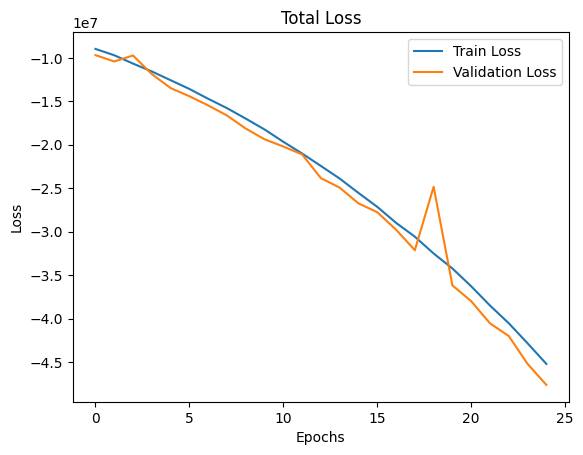

In [24]:
import matplotlib.pyplot as plt

# Total loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Total Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

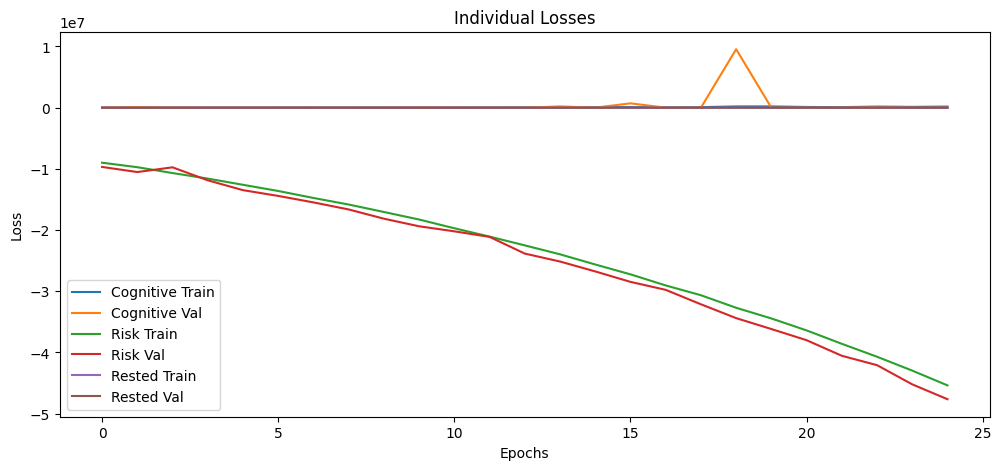

In [25]:
plt.figure(figsize=(12,5))

# Cognitive (regression)
plt.plot(history.history['cognitive_loss'], label='Cognitive Train')
plt.plot(history.history['val_cognitive_loss'], label='Cognitive Val')

# Risk
plt.plot(history.history['risk_loss'], label='Risk Train')
plt.plot(history.history['val_risk_loss'], label='Risk Val')

# Rested
plt.plot(history.history['rested_loss'], label='Rested Train')
plt.plot(history.history['val_rested_loss'], label='Rested Val')

plt.title('Individual Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

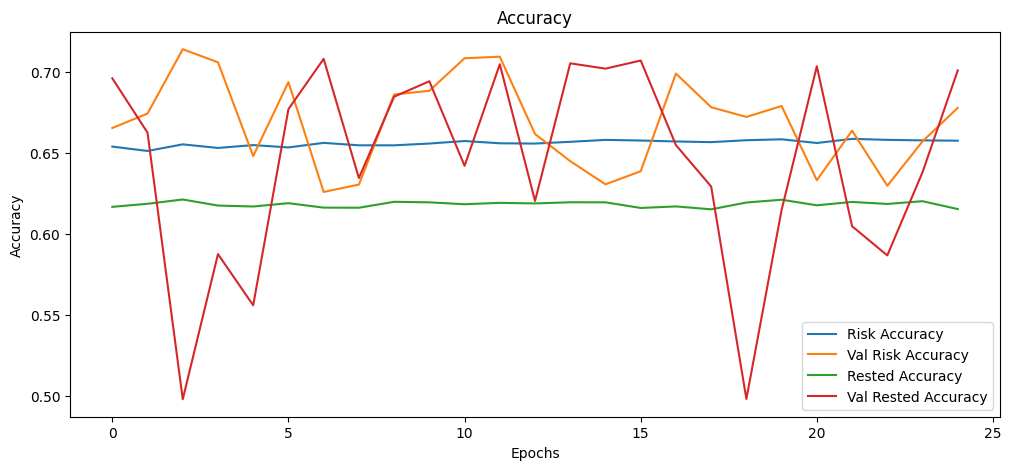

In [26]:
plt.figure(figsize=(12,5))

plt.plot(history.history['risk_accuracy'], label='Risk Accuracy')
plt.plot(history.history['val_risk_accuracy'], label='Val Risk Accuracy')

plt.plot(history.history['rested_accuracy'], label='Rested Accuracy')
plt.plot(history.history['val_rested_accuracy'], label='Val Rested Accuracy')

plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [27]:
print(history.history.keys())

dict_keys(['cognitive_loss', 'cognitive_mae', 'loss', 'rested_accuracy', 'rested_loss', 'risk_accuracy', 'risk_loss', 'val_cognitive_loss', 'val_cognitive_mae', 'val_loss', 'val_rested_accuracy', 'val_rested_loss', 'val_risk_accuracy', 'val_risk_loss'])
